# Librerias

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE
import warnings

In [77]:
warnings.filterwarnings('ignore')

# Preparación de los Datos

## Extracción del Archivo Tratado

In [78]:
url = 'https://raw.githubusercontent.com/armando030/Challenge-Telecom-X-Parte-2/refs/heads/main/datos_tratados.csv'

In [79]:
datos = pd.read_csv(url)

## Eliminación de Columnas Irrelevantes

In [80]:
datos = datos.drop('customerID', axis=1)

## Encoding

In [81]:
datos_codificados = pd.get_dummies(datos, drop_first=True)

In [82]:
datos_codificados

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Total,CuentasDiarias,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.186667,False,False,False,True,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,...,542.40,1.996667,True,False,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.463333,True,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.266667,True,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.796667,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,13,1,0,1,0,0,...,742.90,1.838333,False,False,False,True,False,False,False,True
7263,1,0,1,0,22,1,1,0,0,0,...,1873.70,2.836667,True,True,False,False,False,False,True,False
7264,0,0,0,0,2,1,0,0,1,0,...,92.75,1.676667,True,False,False,False,False,False,False,True
7265,0,0,1,1,67,1,0,1,0,1,...,4627.65,2.261667,True,False,False,False,True,False,False,True


In [83]:
datos_codificados = pd.get_dummies(datos, drop_first=True, dtype=int)

In [84]:
datos_codificados

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Total,CuentasDiarias,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.186667,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542.40,1.996667,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.463333,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.266667,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.796667,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,13,1,0,1,0,0,...,742.90,1.838333,0,0,0,1,0,0,0,1
7263,1,0,1,0,22,1,1,0,0,0,...,1873.70,2.836667,1,1,0,0,0,0,1,0
7264,0,0,0,0,2,1,0,0,1,0,...,92.75,1.676667,1,0,0,0,0,0,0,1
7265,0,0,1,1,67,1,0,1,0,1,...,4627.65,2.261667,1,0,0,0,1,0,0,1


In [85]:
datos_codificados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7267 non-null   int64  
 1   SeniorCitizen                          7267 non-null   int64  
 2   Partner                                7267 non-null   int64  
 3   Dependents                             7267 non-null   int64  
 4   tenure                                 7267 non-null   int64  
 5   PhoneService                           7267 non-null   int64  
 6   MultipleLines                          7267 non-null   int64  
 7   OnlineSecurity                         7267 non-null   int64  
 8   OnlineBackup                           7267 non-null   int64  
 9   DeviceProtection                       7267 non-null   int64  
 10  TechSupport                            7267 non-null   int64  
 11  Stre

## Verificación de la Proporción de Cancelación (Churn)

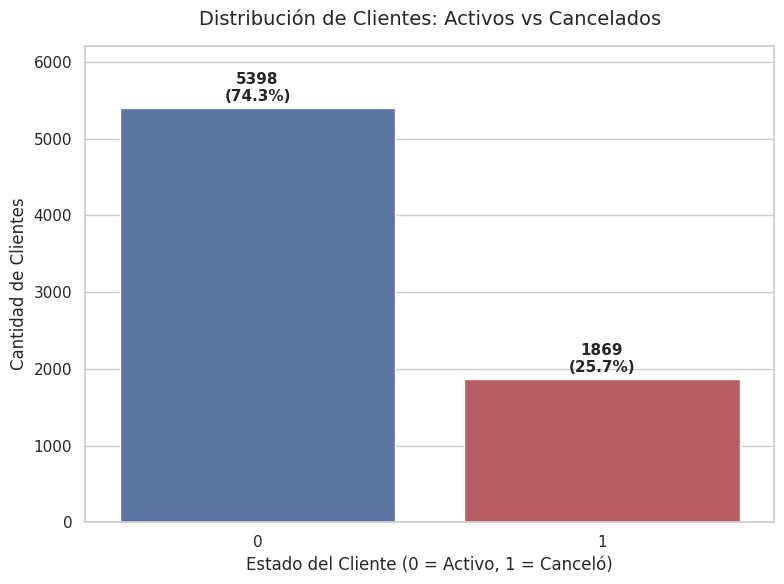

In [86]:
counts = datos_codificados['Churn'].value_counts()
percentages = datos_codificados['Churn'].value_counts(normalize=True) * 100


plt.figure(figsize=(8, 6))
ax = sns.barplot(x=counts.index, y=counts.values, palette=['#4C72B0', '#C44E52'])

plt.title('Distribución de Clientes: Activos vs Cancelados', fontsize=14, pad=15)
plt.xlabel('Estado del Cliente (0 = Activo, 1 = Canceló)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)

for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 50,
            f'{int(height)}\n({percentages[i]:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

plt.ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show();

In [87]:
# 3. Separación de X e y
X = datos_codificados.drop('Churn', axis=1)
y = datos_codificados['Churn']

# 4. División de los datos en Entrenamiento, Validación y Prueba
# Separamos primero un 15% para el conjunto de prueba final simulando datos del mundo real
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5)

# Luego dividimos el resto en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, stratify=y_temp, random_state=5)

# 5. Normalización de los datos
normalizacion = MinMaxScaler()

# Ajustamos y transformamos los datos de entrenamiento
X_train_normalizado = normalizacion.fit_transform(X_train)

# Solo transformamos los de validación y prueba (evitando filtración de datos)
X_val_normalizado = normalizacion.transform(X_val)
X_test_normalizado = normalizacion.transform(X_test)

# (Opcional) Convertir de nuevo a DataFrame para facilitar la lectura
X_train_normalizado = pd.DataFrame(X_train_normalizado, columns=X_train.columns)
X_val_normalizado = pd.DataFrame(X_val_normalizado, columns=X_val.columns)
X_test_normalizado = pd.DataFrame(X_test_normalizado, columns=X_test.columns)

In [88]:
datos_codificados

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Total,CuentasDiarias,gender_Male,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,0,0,1,0,...,593.30,2.186667,0,0,0,1,0,0,0,1
1,0,0,0,0,9,1,1,0,0,0,...,542.40,1.996667,1,0,0,0,0,0,0,1
2,1,0,0,0,4,1,0,0,0,1,...,280.85,2.463333,1,1,0,0,0,0,1,0
3,1,1,1,0,13,1,0,0,1,1,...,1237.85,3.266667,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,0,0,0,0,...,267.40,2.796667,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,13,1,0,1,0,0,...,742.90,1.838333,0,0,0,1,0,0,0,1
7263,1,0,1,0,22,1,1,0,0,0,...,1873.70,2.836667,1,1,0,0,0,0,1,0
7264,0,0,0,0,2,1,0,0,1,0,...,92.75,1.676667,1,0,0,0,0,0,0,1
7265,0,0,1,1,67,1,0,1,0,1,...,4627.65,2.261667,1,0,0,0,1,0,0,1


# Correlación y Selección de Variables

## Análisis de Correlación

In [89]:
correlacion = datos_codificados.corr()['Churn'].sort_values(ascending=False)

In [90]:
correlacion

,Churn
Churn,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
CuentasDiarias,0.189866
Monthly,0.189866
PaperlessBilling,0.186666
SeniorCitizen,0.146733
StreamingTV,0.062430
StreamingMovies,0.060586
MultipleLines,0.039343


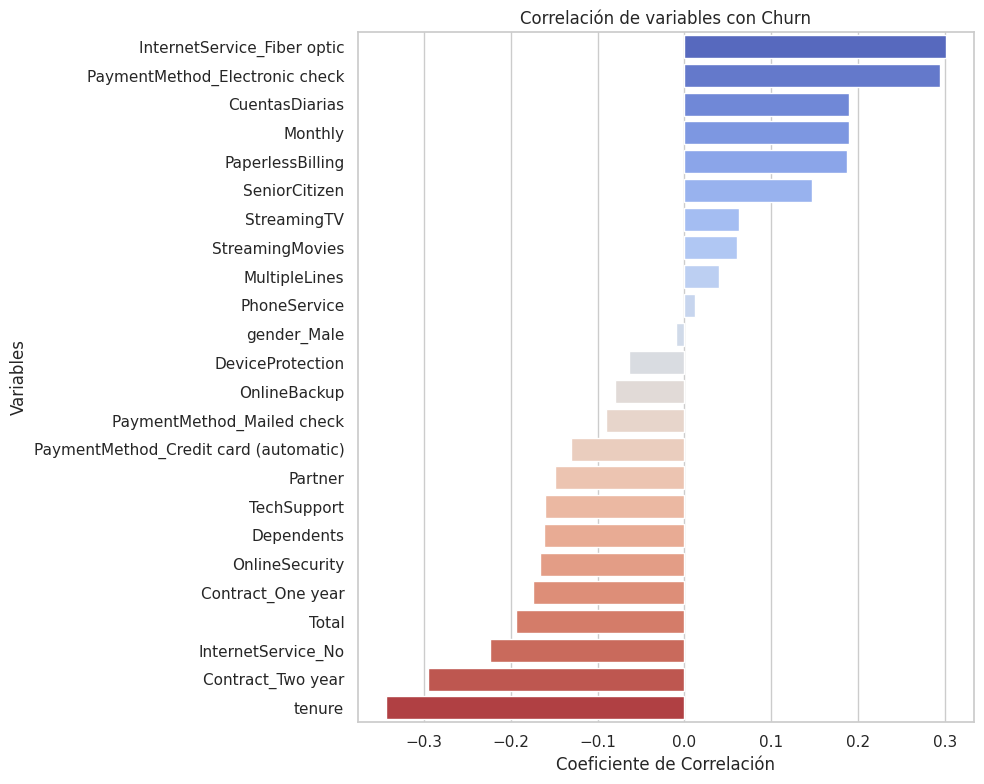

In [91]:
plt.figure(figsize=(10, 8))
correlacion_plot = correlacion.drop('Churn')
sns.barplot(x=correlacion_plot.values, y=correlacion_plot.index, palette='coolwarm')
plt.title('Correlación de variables con Churn')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variables')
plt.tight_layout()
plt.show();

## Análisis Dirigido

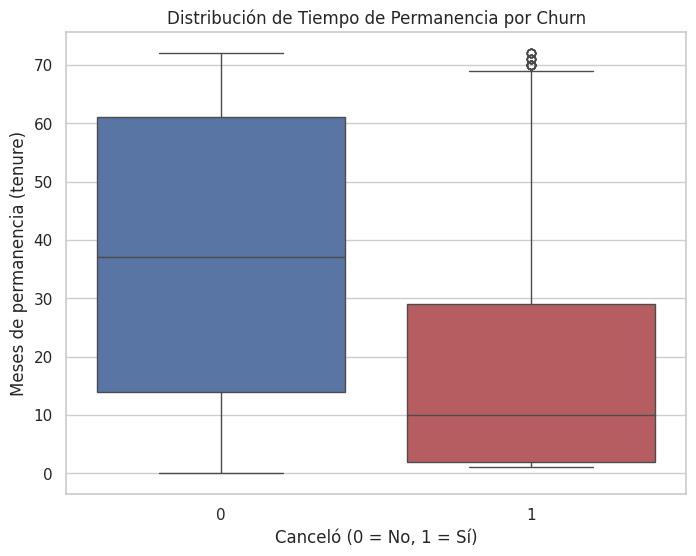

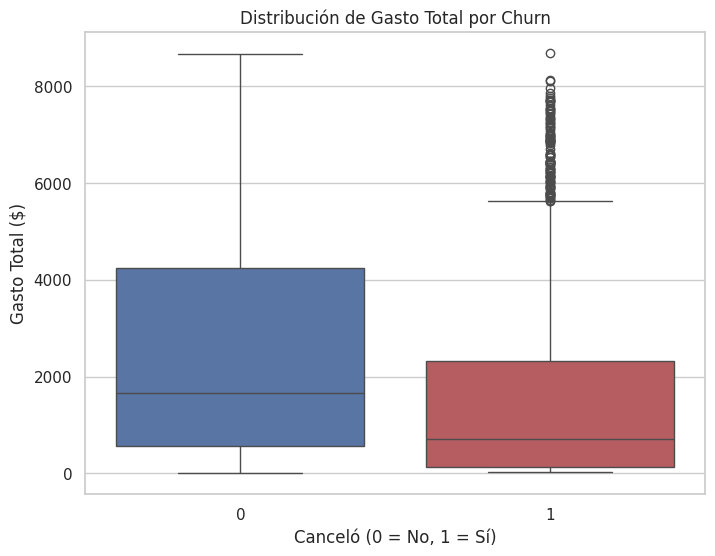

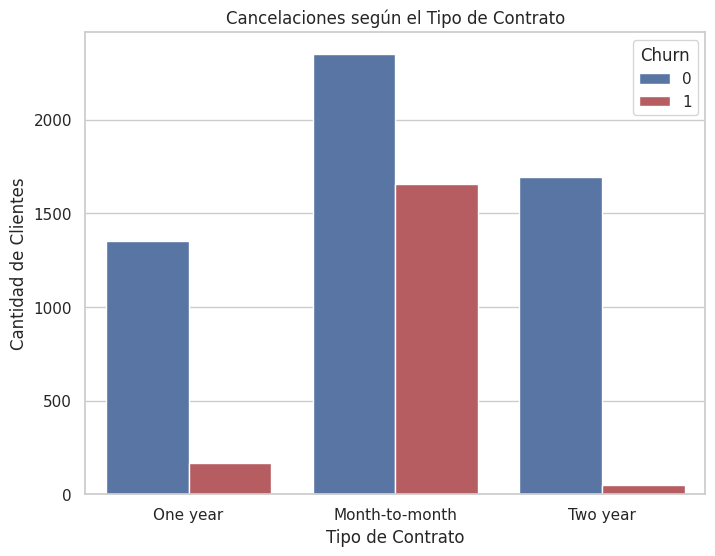

In [92]:
df = pd.read_csv(url)
sns.set_theme(style="whitegrid")

# 1. Boxplot: Tiempo de permanencia vs Cancelación
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Distribución de Tiempo de Permanencia por Churn')
plt.xlabel('Canceló (0 = No, 1 = Sí)')
plt.ylabel('Meses de permanencia (tenure)')
plt.show()

# 2. Boxplot: Gasto Total vs Cancelación
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Total', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Distribución de Gasto Total por Churn')
plt.xlabel('Canceló (0 = No, 1 = Sí)')
plt.ylabel('Gasto Total ($)')
plt.show()

# 3. Barplot: Tipo de Contrato vs Cancelación
plt.figure(figsize=(8, 6))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#4C72B0', '#C44E52'])
plt.title('Cancelaciones según el Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Modelado Predictivo

## Separación de Datos

In [93]:
X = datos_codificados.drop('Churn', axis=1)
y = datos_codificados['Churn']

# División de los datos en Entrenamiento y Prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


## Creación de Modelos

### Balanceo de Clases

In [94]:
smote = SMOTE(random_state=42)
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

print(f"Cantidad de datos antes de SMOTE: {y_train.value_counts().to_dict()}")
print(f"Cantidad de datos después de SMOTE: {y_train_balanceado.value_counts().to_dict()}")

Cantidad de datos antes de SMOTE: {0: 4318, 1: 1495}
Cantidad de datos después de SMOTE: {0: 4318, 1: 4318}


### Creaciòn y Entrenamiento del Modelo

In [95]:
# Utilizamos un Árbol de Decisión. Limitamos la profundidad (max_depth=5)
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train_balanceado, y_train_balanceado)

# Predicciones sobre el conjunto de prueba
y_pred = modelo_arbol.predict(X_test)

## Evaluación del Modelo

### Reporte de Clasificación

In [96]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1080
           1       0.50      0.72      0.59       374

    accuracy                           0.74      1454
   macro avg       0.69      0.74      0.70      1454
weighted avg       0.79      0.74      0.76      1454



### Matriz de Confusión

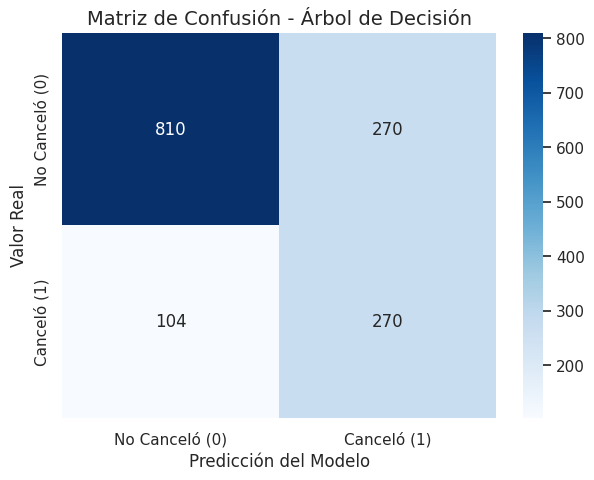

In [97]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Canceló (0)', 'Canceló (1)'],
            yticklabels=['No Canceló (0)', 'Canceló (1)'])
plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=14)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.show()

# Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

In [98]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_balanceado), columns=X_train_balanceado.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

### Regresión Logistica

In [99]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_balanceado)

importancia_lr = pd.DataFrame({'Variable': X_train_scaled.columns, 'Coeficiente': lr.coef_[0]})

# Ordenamos usando valor absoluto
importancia_lr['Absoluto'] = importancia_lr['Coeficiente'].abs()
importancia_lr = importancia_lr.sort_values(by='Absoluto', ascending=False).head(10)

### Random Forest

In [100]:
rf = RandomForestClassifier(random_state=42, max_depth=5)
rf.fit(X_train_balanceado, y_train_balanceado)

importancia_rf = pd.DataFrame({'Variable': X_train_balanceado.columns, 'Importancia': rf.feature_importances_})
importancia_rf = importancia_rf.sort_values(by='Importancia', ascending=False).head(10)

### Resultados

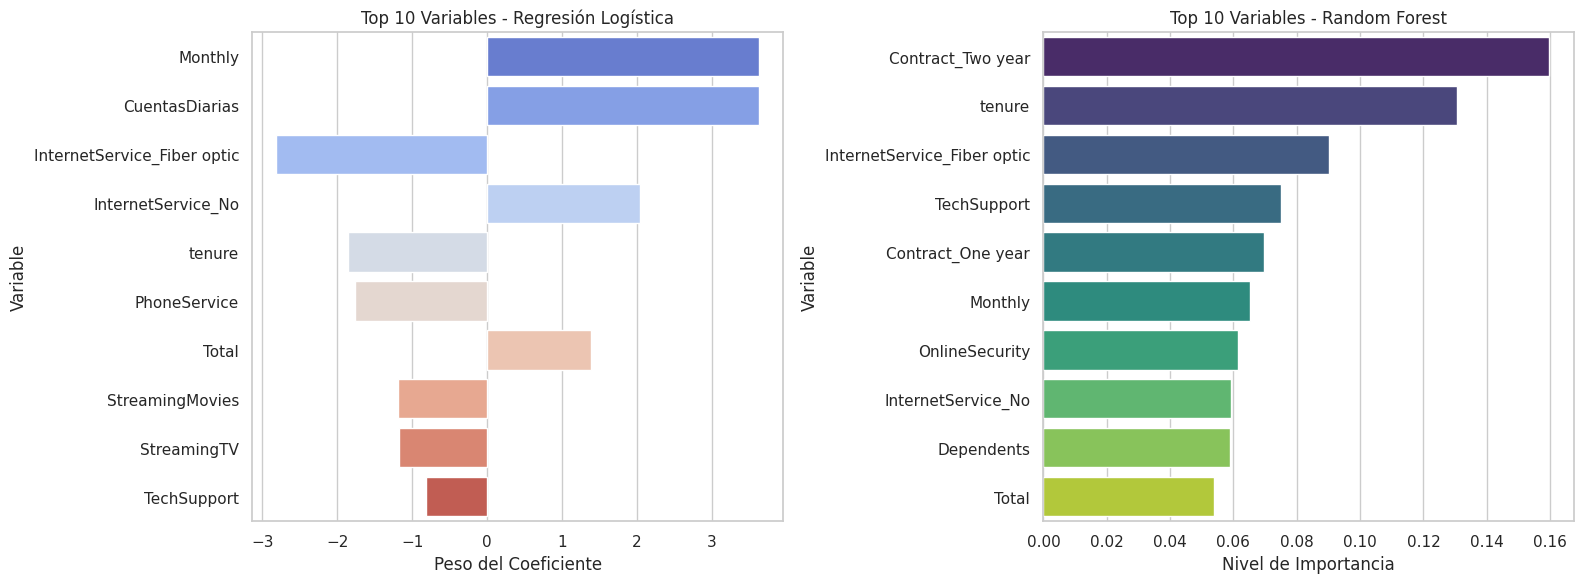

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Coeficiente', y='Variable', data=importancia_lr, ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 10 Variables - Regresión Logística')
axes[0].set_xlabel('Peso del Coeficiente')

sns.barplot(x='Importancia', y='Variable', data=importancia_rf, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Variables - Random Forest')
axes[1].set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show();

### KNN (K-Nearest Neighbors)

In [102]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_balanceado)

resultados_permutacion = permutation_importance(knn, X_test_scaled, y_test, n_repeats=10, random_state=42)

importancia_knn = pd.DataFrame({'Variable': X_test_scaled.columns, 'Importancia': resultados_permutacion.importances_mean})
importancia_knn = importancia_knn.sort_values(by='Importancia', ascending=False).head(5)
print("\nTop 5 variables más importantes para KNN (por permutación):")
print(importancia_knn)


Top 5 variables más importantes para KNN (por permutación):
                      Variable  Importancia
23  PaymentMethod_Mailed check     0.017125
19           Contract_One year     0.016919
7                 OnlineBackup     0.015681
20           Contract_Two year     0.015199
6               OnlineSecurity     0.014305
